In [1]:
import os
import sys
import torch
# import logging
import torch.nn as nn
# import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
# from torch.autograd import Variable
# import torchvision.models as models

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.special import gamma, gammaln

import copy
import datetime
import yaml

import importlib

In [2]:
dirP_str = os.path.join(os.environ['HOME'], 
                    'Python',
                    'aerosol-scattering',
                    'library')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)
    
import evid_nn
import loss as losslib
import polynomial as p

In [3]:
importlib.reload(evid_nn)

<module 'evid_nn' from '/glade/u/home/mhayman/Python/aerosol-scattering/library/evid_nn.py'>

In [4]:
is_cuda = torch.cuda.is_available()
device = torch.device(torch.cuda.current_device()) if is_cuda else torch.device("cpu")

if is_cuda:
    torch.backends.cudnn.benchmark = True

print(f'Preparing to use device {device}')

dtype = torch.float

Preparing to use device cuda:0


In [5]:
data_path = "/glade/derecho/scratch/mhayman/aerosol/datasets/"

In [6]:
data_file = "hippo_aerosol_training_data.nc"

In [7]:
train_ds = xr.open_dataset(os.path.join(data_path,data_file))

In [8]:
def transpose_and_flatten_data_array(da: xr.DataArray,flattened_dim_name:str = None) -> xr.DataArray:
    """
    Transposes an xarray DataArray so the first dimension is 'data_index'
    and all other dimensions are flattened into a single second dimension
    named 'flattened_dims'.

    Args:
        da (xr.DataArray): The input DataArray.

    Returns:
        xr.DataArray: The reshaped DataArray with dimensions ('data_index', 'flattened_dims').
                      The 'flattened_dims' dimension will have a MultiIndex if multiple
                      dimensions were stacked, preserving original coordinate information.
    """

    # --- Handle Scalar DataArray ---
    # If the DataArray is a scalar (no dimensions), expand it to a (1,1) array
    # with the desired dimension names.
    if not da.dims:
        return da.expand_dims({'data_index': 1, 'flattened_dims': 1})

    # --- Prepare Dimensions ---
    original_dims = list(da.dims)
    data_index_dim_name = 'data_index'
    if flattened_dim_name is None:
        flattened_dim_name = 'input_vars'

    # Step 1: Ensure 'data_index' is a dimension and is the first dimension.
    if data_index_dim_name not in original_dims:
        # If 'data_index' is not present, assume the current first dimension
        # should be renamed to 'data_index'.
        first_dim_original_name = original_dims[0]
        da = da.rename({first_dim_original_name: data_index_dim_name})
        # Update the list of original_dims to reflect the rename
        original_dims = list(da.dims)
    
    # Now, 'data_index' is guaranteed to be a dimension in `da`.
    # Ensure 'data_index' is the very first dimension.
    if da.dims[0] != data_index_dim_name:
        # Use .transpose() to move 'data_index' to the first position,
        # keeping the relative order of other dimensions.
        da = da.transpose(data_index_dim_name, *[d for d in da.dims if d != data_index_dim_name])

    # --- Flatten Other Dimensions ---
    # Identify all dimensions that are NOT 'data_index'. These will be flattened.
    dims_to_flatten = [d for d in da.dims if d != data_index_dim_name]

    if not dims_to_flatten:
        # If there are no other dimensions (e.g., the original array was already
        # just ('data_index',)), we need to add a 'flattened_dims' dimension
        # of size 1 to achieve the target 2D structure.
        # We use axis=1 to add it as the second dimension.
        return da.expand_dims(flattened_dim_name, axis=1)

    # Use .stack() to combine the identified dimensions into a single new dimension.
    # xarray's .stack() method automatically creates a MultiIndex for the new dimension,
    # which is excellent for preserving the original coordinate information.
    # The new stacked dimension will be added as the last dimension by default.
    # Since 'data_index' was already moved to the first position, the final order
    # will be (data_index, flattened_dims), which is the desired outcome.
    stacked_da = da.stack({flattened_dim_name: dims_to_flatten})

    return stacked_da

# Setup data loaders

In [121]:
config = "evid_config/hippo_polynomial_config.yml"

In [122]:
with open(config) as cf:
    conf = yaml.load(cf, Loader=yaml.FullLoader)

In [123]:
input_var_lst = conf['data']['input_cols']
label_var_lst = conf['data']['output_cols']

train_batch_size = conf['data']['batch_size']
valid_batch_size = conf['data']['batch_size']
test_batch_size = conf['data']['batch_size']

train_idx = int(np.round(train_ds.sizes['data_index']*conf['data']['train_fraction']))
valid_idx = train_idx+int(np.round(train_ds.sizes['data_index']*conf['data']['valid_fraction']))
test_idx = train_idx+int(np.round(train_ds.sizes['data_index']*conf['data']['test_fraction']))


In [124]:
ds = train_ds

input_lst = []
for var in input_var_lst:
    input_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='input_vars'))

train_input_arr = xr.concat(input_lst,'input_vars')
# train_input_arr = xr.concat(input_lst,pd.Index(input_var_lst,name='input_vars')).transpose('data_index','input_vars')

output_lst = []
for var in label_var_lst:
    output_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='label_vars'))

train_label_arr = xr.concat(output_lst,pd.Index(label_var_lst,name='label_vars'))

In [125]:
x_scaler = evid_nn.rescale(0,1,axes=(0,))
y_scaler = evid_nn.rescale(0,1,axes=(0,))

x_scaler.set_scale(np.log(train_input_arr.values))
y_scaler.set_scale(np.log(train_label_arr.values))

# 1D profiles
# x_train_reshape_args = (-1,len(input_var_lst),)
# x_valid_reshape_args = (-1,len(input_var_lst),)
# x_test_reshape_args = (-1,len(input_var_lst),)
# y_train_reshape_args = (-1,len(label_var_lst),)
# y_valid_reshape_args = (-1,len(label_var_lst),)
# y_test_reshape_args = (-1,len(label_var_lst),)

x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
x_test = x_scaler.scale(np.log(train_input_arr.values[valid_idx:,:]))


y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
y_test = y_scaler.scale(np.log(train_label_arr.values[valid_idx:,:]))
# y_train = y_scaler.scale(np.log(train_label_arr.values)).reshape(*y_train_reshape_args)
# y_valid = y_scaler.scale(np.log(valid_label_arr.values)).reshape(*y_valid_reshape_args)
# y_test = y_scaler.scale(np.log(test_label_arr.values)).reshape(*y_test_reshape_args)

In [126]:
cond_args = {
    'in_norm_arr':1,
    'in_bias_arr':0,
    'out_norm_arr':1,
    'out_bias_arr':0,
}

In [127]:
train_dataset = evid_nn.EvidDataset(x_train,y_train,
                            dtype=dtype,device=device,
                              **cond_args)
valid_dataset = evid_nn.EvidDataset(x_valid,y_valid,
                            dtype=dtype,device=device,
                              **cond_args)
test_dataset = evid_nn.EvidDataset(x_test,y_test,
                            dtype=dtype,device=device,
                              **cond_args)

In [128]:
train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

# Build and Train Model

In [129]:
# importlib.reload(evid_nn)

In [130]:
mean_loss_reg_lst = []
std_loss_reg_lst = []
reg_lst = []

In [131]:
# layer_lst = [16,32,64]
layer_lst = conf['model']['layer_lst'] # [128,512,512,]# [512,512,]
polynomial_order = [conf['model']['polynomial_order_1'], conf['model']['polynomial_order_2']]

# note the factor of 2 on output for evidential output
model = evid_nn.PolyPDF_dense_net(input_channels=x_train.shape[1],
                                  layer_lst=layer_lst,
                                  output_channels=y_train.shape[1],
                                  polynomial_order=polynomial_order,
                                  dtype=dtype,device=device,
                                  int_count=conf['model']['int_count'])

learning_rate = conf['training']['learning_rate'] # 1e-4
max_epochs = conf['training']['max_epochs'] # 1500

In [132]:
model.to(device);

In [133]:
model.x_mesh_ch_poly.T.shape

torch.Size([484, 1000000])

In [134]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
    factor=0.1, patience=100, threshold=1e-3, threshold_mode='abs',min_lr=1e-8)

In [135]:
# loss_fnc = losslib.RegEvidentialLoss
# val_loss_fnc = losslib.EvidentialLoss

In [136]:
model.train()

# loss_dct = {'train_loss':[],'train_kld':[],'train_pois':[],
#             'vld_loss':[],'vld_kld':[],'vld_pois':[]}

loss_dct = {'train_loss':[],'train_ref_loss':[],
            'vld_loss':[],'vld_ref_loss':[]}

In [137]:
for idx in range(max_epochs):
    (in_data,label_data) = next(iter(train_dataloader))
    
    optimizer.zero_grad()
    
    est = model(in_data,label_data)
    
    total_loss = est # loss_fnc(est,label_data,reg_coef)
    
    
    loss = total_loss
    loss_dct['train_loss'].append(total_loss.item())
#     loss_dct['train_ref_loss'].append(ref_loss.item())

    
    loss.backward()

    optimizer.step()
    scheduler.step(loss)
    
    with torch.no_grad():
        (in_data,label_data) = next(iter(valid_dataloader))
        est = model(in_data,label_data)

        total_loss = est # val_loss_fnc(est,label_data)


        loss_dct['vld_loss'].append(total_loss.item())
#         loss_dct['vld_ref_loss'].append(ref_loss.item())

        scheduler.step(total_loss)
    
    
    
    if (idx+1) % 50 == 0:
        print('%d iterations' % (idx+1), end=" ")
        print('loss: %.3e'%loss_dct['train_loss'][-1], end=", ")
        print('validation loss: %.3e'%loss_dct['vld_loss'][-1])
        # print()
#         print('ref: %.3e'%loss_dct['train_ref_loss'][-1], end=", ")
        # print('validation loss: %.3e'%loss_dct['vld_loss'][-1])
#         print('ref loss: %.3e'%loss_dct['vld_ref_loss'][-1])

50 iterations loss: -5.869e+02, validation loss: -6.356e+02
100 iterations loss: -7.622e+02, validation loss: -7.749e+02
150 iterations loss: -7.725e+02, validation loss: -8.174e+02
200 iterations loss: -8.077e+02, validation loss: -8.378e+02
250 iterations loss: -9.152e+02, validation loss: -8.738e+02
300 iterations loss: -9.459e+02, validation loss: -9.482e+02
350 iterations loss: -9.861e+02, validation loss: -9.335e+02
400 iterations loss: -9.673e+02, validation loss: -9.870e+02
450 iterations loss: -1.005e+03, validation loss: -9.877e+02
500 iterations loss: -1.039e+03, validation loss: -1.020e+03
550 iterations loss: -9.734e+02, validation loss: -1.005e+03
600 iterations loss: -1.056e+03, validation loss: -1.014e+03
650 iterations loss: -1.057e+03, validation loss: -1.059e+03
700 iterations loss: -1.033e+03, validation loss: -1.048e+03
750 iterations loss: -1.028e+03, validation loss: -9.938e+02
800 iterations loss: -1.047e+03, validation loss: -1.026e+03
850 iterations loss: -1.0

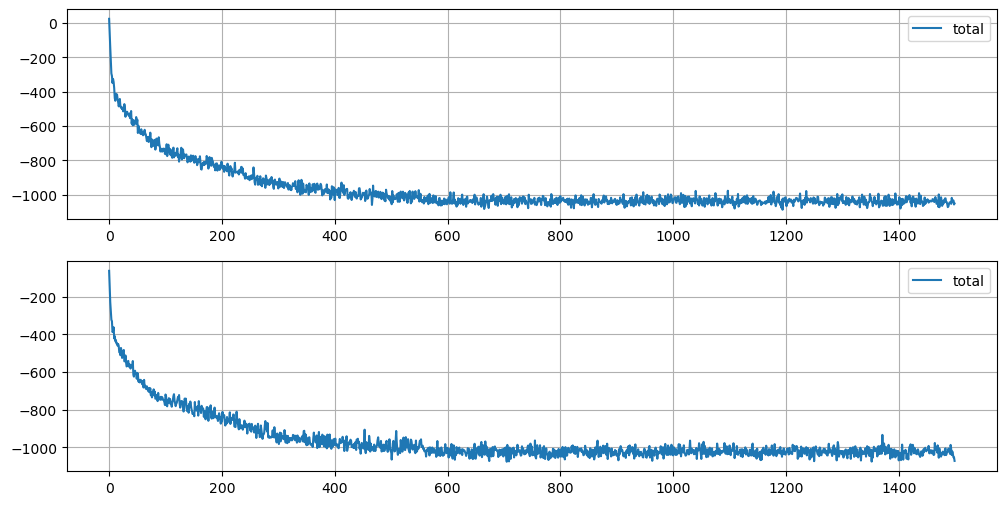

In [138]:
fig,ax = plt.subplots(2,1,figsize=(12,6))
ax[0].plot(loss_dct['train_loss'],label='total')
# ax[0].plot(loss_dct['train_ref_loss'],label='reference')
# ax[0].plot(np.array(loss_dct['train_kld'])*kld_weight,label='KLD')
# ax[0].plot(loss_dct['train_pois'],label='Poisson')
ax[0].grid(visible=True)
ax[0].legend()
# ax[0].set_yscale('log')
# ax[0].set_ylim([-1e-5,1e-5])

ax[1].plot(loss_dct['vld_loss'],label='total')
# ax[1].plot(loss_dct['vld_ref_loss'],label='reference')
# ax[1].plot(np.array(loss_dct['vld_kld'])*kld_weight,label='KLD')
# ax[1].plot(loss_dct['vld_pois'],label='Poisson')
ax[1].grid(visible=True)
ax[1].legend()
# ax[1].set_yscale('log')
# ax[1].set_ylim([-10,5])

In [176]:
in_data = x_train
out_label = y_train

# idx = 1834
# idx = 131398
# idx = 974538
idx = int(np.random.rand()*in_data.shape[0])  # get random input
print(f"index: {idx}")
sim_idx = np.where(np.prod(np.abs(in_data - in_data[idx,:].reshape(1,-1)) < 0.01,axis=1))
r_sim = out_label[:,1][sim_idx]
n_sim = out_label[:,0][sim_idx]

# r_sim = out_label[:,1]
# n_sim = out_label[:,0]

index: 813561


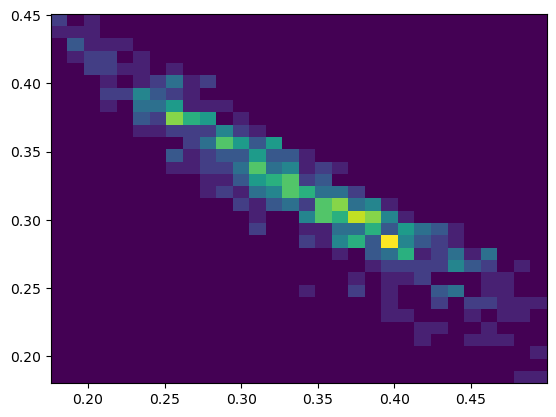

In [177]:
# h_part = np.histogram2d(r_sim,n_sim,bins=30)
h_part = np.histogram2d(r_sim,n_sim,bins=30)
plt.figure()
plt.pcolormesh(h_part[1],h_part[2],h_part[0].T)

In [178]:
# fit_coef = model.net(torch.tensor(in_data[idx:(idx+10),:],dtype=dtype,device=device))
# f_pdf_0 = torch.exp(fit_coef @ model.x_mesh_ch_poly.T)
# f_pdf_tnsr = f_pdf_0.reshape(fit_coef.shape[0],model.x_int.shape[0],model.x_int.shape[0])
# f_pdf_int = model.fpdf_integral(fit_coef)
# f_pdf_norm = f_pdf_tnsr/f_pdf_int.reshape(-1,1,1)
# f_pdf = f_pdf_norm[0,...].detach().cpu().numpy()

f_pdf_tnsr = model.output_pdf(torch.tensor(in_data[idx:(idx+10),:],dtype=dtype,device=device))
f_pdf = f_pdf_tnsr.detach().cpu().numpy()
x_plt = model.x_int.detach().cpu().numpy()

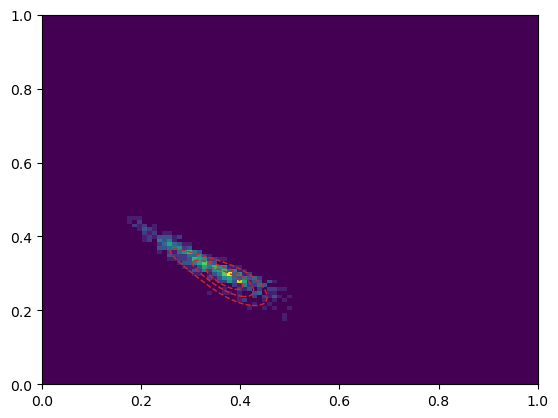

In [179]:
h_part = np.histogram2d(r_sim,n_sim,bins=np.linspace(0,1,100))
plt.figure()
plt.pcolormesh(h_part[1],h_part[2],h_part[0].T)
contours = plt.contour(x_plt, x_plt, f_pdf[0,...], levels = 3, colors='tab:red', linestyles='dashed', linewidths=1)
# plt.clabel(contours, inline=True, fontsize=8, fmt='%1.1f') # Add labels to contour lines

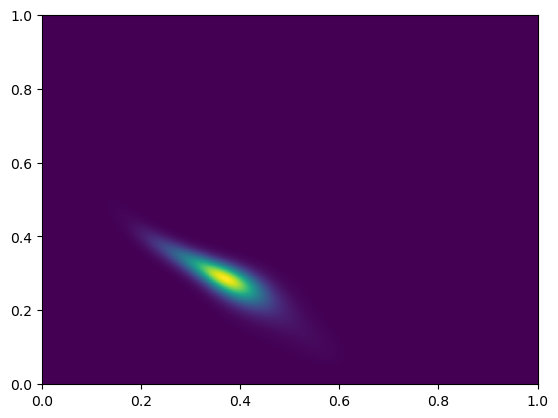

In [180]:
plt.figure()
plt.pcolormesh(x_plt,x_plt,f_pdf[0,...])

In [181]:
np.mean(np.diff(h_part[0]))

np.float64(0.0)

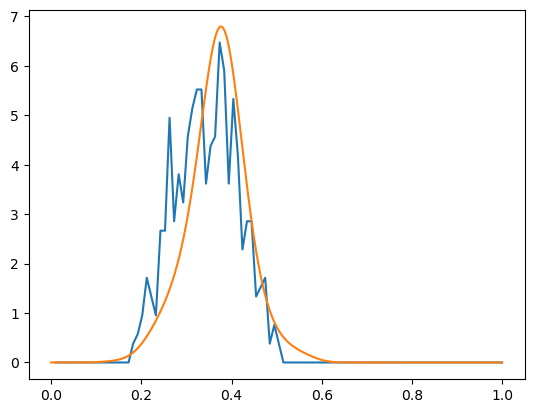

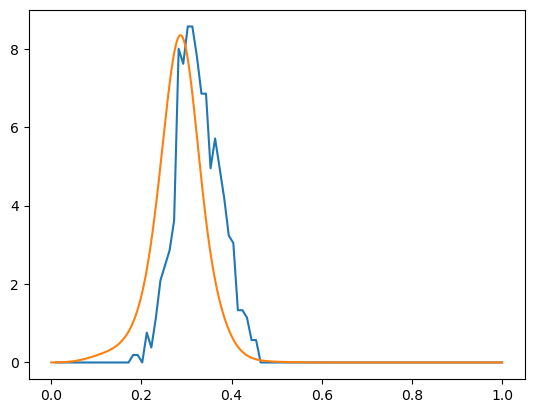

In [182]:
plt.figure()
plt.plot(h_part[1][1:],np.sum(h_part[0].T,axis=0)/np.sum(h_part[0])/np.mean(np.diff(h_part[1])))
plt.plot(x_plt,np.sum(f_pdf[0,...],axis=0)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)))

plt.figure()
plt.plot(h_part[1][1:],np.sum(h_part[0].T,axis=1)/np.sum(h_part[0])/np.mean(np.diff(h_part[1])))
plt.plot(x_plt,np.sum(f_pdf[0,...],axis=1)/np.sum(f_pdf[0,...])/np.mean(np.diff(x_plt)))

In [38]:
in_data = x_train
out_label = y_train
est = model(torch.tensor(in_data,dtype=dtype,device=device)).detach().cpu().numpy()

# if output_bias_channel_cnt == 0:
#     log_alpha, log_beta = np.split(est,2,axis=-1)
# elif output_bias_channel_cnt == 1:
log_alpha, log_beta, gamma_mean, log_v = np.split(est,4,axis=-1)

x_input = in_data.reshape(x_train.shape[0],-1,len(input_var_lst))

y_input = in_data.reshape(x_train.shape[0],-1,len(input_var_lst))

mean_valid = gamma_mean
std_a_valid = np.sqrt(np.exp(log_beta)/(np.exp(log_alpha)))
std_e_valid = np.sqrt(np.exp(log_beta)/(np.exp(log_v)*(np.exp(log_alpha))))
std_t_valid = np.sqrt(np.exp(log_beta)*(1+np.exp(log_v))/(2*np.exp(log_v)*(np.exp(log_alpha))))

mean_valid_noscale = np.exp(y_scaler.unscale(mean_valid))
std_a_valid_noscale = y_scaler.unscale(std_a_valid)
std_e_valid_noscale = y_scaler.unscale(std_e_valid)
std_t_valid_noscale = y_scaler.unscale(std_t_valid)

label_unscale = np.exp(y_scaler.unscale(out_label))

# mean_valid_noscale = y_scaler.unscale(mean_valid[...,np.newaxis])
# std_a_valid_noscale = y_scaler.unscale(std_a_valid[...,np.newaxis])
# std_e_valid_noscale = y_scaler.unscale(std_e_valid[...,np.newaxis])
# std_t_valid_noscale = y_scaler.unscale(std_t_valid[...,np.newaxis])

# std_g_valid = np.sqrt(np.exp(log_beta)/np.exp(log_alpha))

x_valid_noscale = x_scaler.unscale(x_input)
# std_g_valid_noscale = y_scaler.unscale(std_g_valid[...,np.newaxis])

# std_e_valid = np.sqrt(np.exp(log_beta)*gamma(np.exp(log_alpha)-1)/gamma(np.exp(log_alpha)))  # Evidential Variance
# std_e_valid_noscale = y_scaler.unscale(std_e_valid[...,np.newaxis]).squeeze()

y_valid_noscale = y_scaler.unscale(y_train[...,np.newaxis])

In [ ]:
x_train.shape

In [39]:
# idx = 1834
idx = np.random.rand()*
sim_idx = np.where(np.prod(np.abs(x_train - x_train[idx,:].reshape(1,-1)) < 0.01,axis=1))
r_sim = out_label[:,1][sim_idx]
n_sim = out_label[:,0][sim_idx]

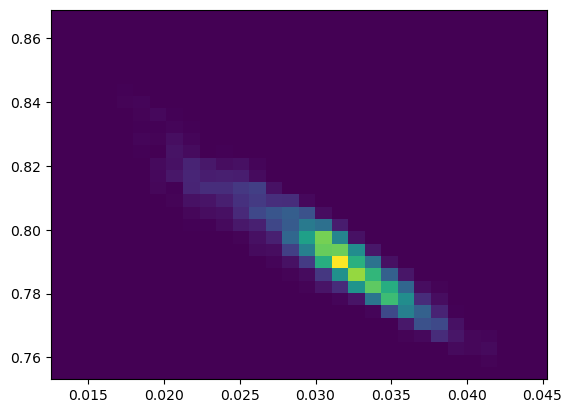

In [40]:
h_part = np.histogram2d(r_sim,n_sim,bins=30)
plt.figure()
plt.pcolormesh(h_part[1],h_part[2],h_part[0].T)

In [41]:
mean_valid[idx,1]

np.float32(0.030949946)

In [42]:
std_e_valid[idx,1]

np.float32(0.0036332223)

/glade/derecho/scratch/mhayman/tmp/ipykernel_26987/1884840625.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(h_part[1][:-1],h_part[0]/np.trapz(h_part[0],h_part[1][:-1]))


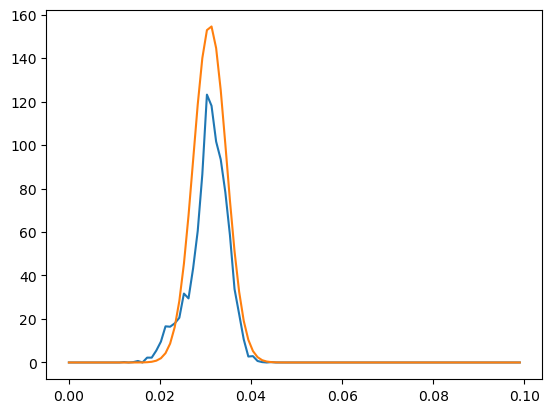

In [43]:

mean_valid[idx,1]
std_e_valid[idx,1]
h_part = np.histogram(r_sim,bins=np.linspace(0,0.1,100))
plt.figure()
plt.plot(h_part[1][:-1],h_part[0]/np.trapz(h_part[0],h_part[1][:-1]))
# plt.plot(h_part[1][:-1],h_part[0]/np.sum(h_part[0]))
plt.plot(h_part[1][:-1],1/np.sqrt(np.pi*std_e_valid[idx,1]**2) * np.exp(-(h_part[1][:-1]-mean_valid[idx,1])**2/(2*std_e_valid[idx,1]**2)))


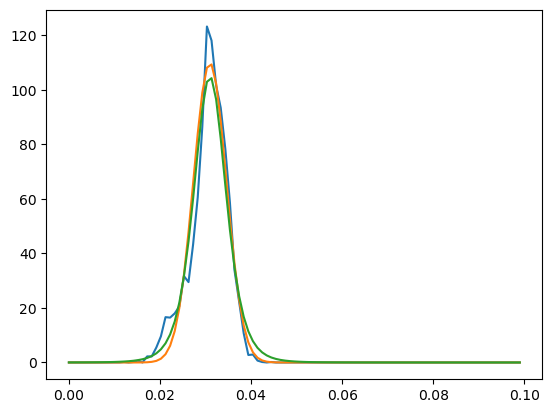

In [44]:
h_part = np.histogram(r_sim,bins=np.linspace(0,0.1,100))

x = h_part[1][:-1]
t_ax = (x - mean_valid[idx,1])/std_e_valid[idx,1]
nu = np.exp(log_v[idx,1])
t_distr = gamma((nu+1)/2)/(np.pi*nu)/gamma(nu/2) * (1 + t_ax**2/nu)**(-(nu+1)/2)

norm_distr = 1/np.sqrt(np.pi*std_e_valid[idx,1]**2) * np.exp(-(x-mean_valid[idx,1])**2/(2*std_e_valid[idx,1]**2))

plt.figure()
plt.plot(h_part[1][:-1],h_part[0]/np.trapezoid(h_part[0],h_part[1][:-1]))
plt.plot(h_part[1][:-1],norm_distr/np.trapezoid(norm_distr,x))
plt.plot(h_part[1][:-1],t_distr/np.trapezoid(t_distr,x))


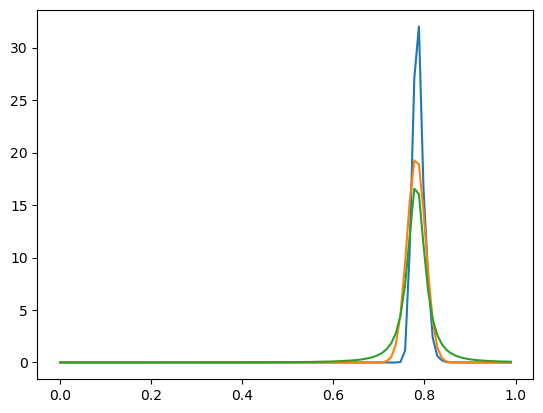

In [45]:
h_part = np.histogram(n_sim,bins=np.linspace(0,1,100))

x = h_part[1][:-1]
t_ax = (x - mean_valid[idx,0])/std_e_valid[idx,0]
nu = np.exp(log_v[idx,0])
t_distr = gamma((nu+1)/2)/(np.pi*nu)/gamma(nu/2) * (1 + t_ax**2/nu)**(-(nu+1)/2)

norm_distr = 1/np.sqrt(np.pi*std_e_valid[idx,0]**2) * np.exp(-(x-mean_valid[idx,0])**2/(2*std_e_valid[idx,0]**2))

plt.figure()
plt.plot(h_part[1][:-1],h_part[0]/np.trapezoid(h_part[0],h_part[1][:-1]))
plt.plot(h_part[1][:-1],norm_distr/np.trapezoid(norm_distr,x))
plt.plot(h_part[1][:-1],t_distr/np.trapezoid(t_distr,x))

In [111]:
nu

array([11.113016, 20.627295], dtype=float32)

In [91]:
np.trapz(h_part[0])

/glade/derecho/scratch/mhayman/tmp/ipykernel_9387/1503039843.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(h_part[0])


np.float64(14257.0)

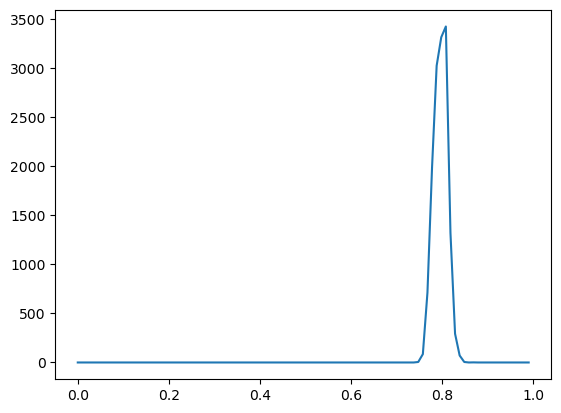

In [84]:
h_part = np.histogram(n_sim,bins=np.linspace(0,1,100))
plt.figure()
plt.plot(h_part[1][:-1],h_part[0])

In [81]:
np.abs(x_train - x_train[idx,:].reshape(1,-1)) < 0.5

array([[ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       ...,
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True]])

In [69]:
x_train[idx,:]

array([0.44580856, 0.48787481, 0.51729888, 0.52820537, 0.62015885,
       0.65381942])

In [70]:
np.exp(y_scaler.unscale(y_train[idx,:]))

array([[3.6450005e+01, 7.6581770e-08]], dtype=float32)

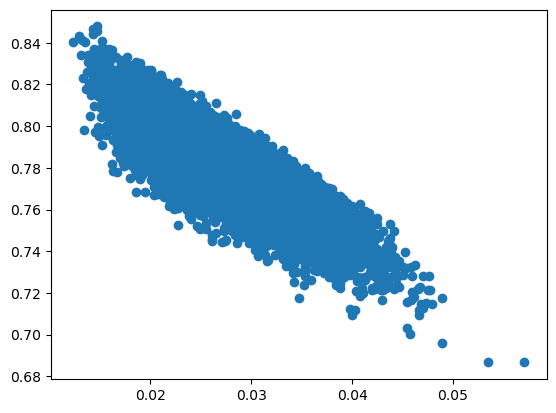

In [71]:
plt.figure()
plt.scatter(r_sim,n_sim)

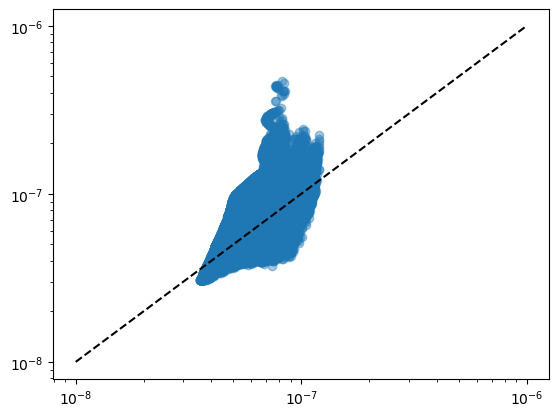

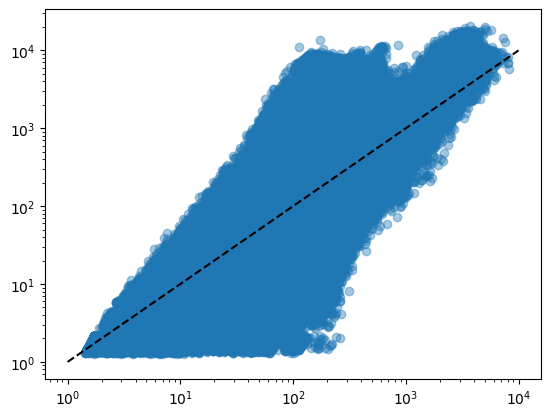

In [144]:
# predict mean radius
plt.figure()
plt.scatter(mean_valid_noscale[:,1],label_unscale[:,1],alpha=0.4)
plt.plot([1e-8,1e-6],[1e-8,1e-6],'k--')
plt.xscale('log')
plt.yscale('log')

# predict concentration
plt.figure()
plt.scatter(mean_valid_noscale[:,0],label_unscale[:,0],alpha=0.4)
plt.plot([1e0,1e4],[1e0,1e4],'k--')
plt.xscale('log')
plt.yscale('log')

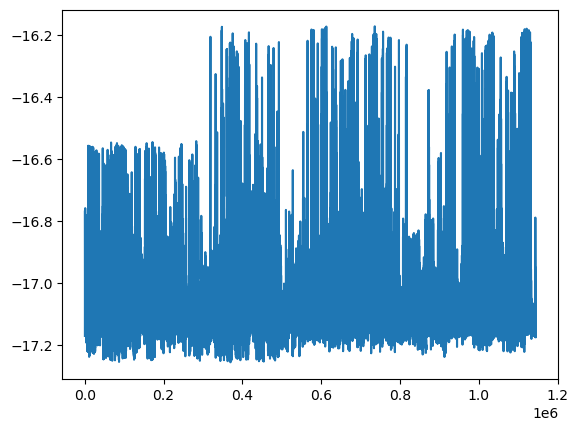

In [145]:
plt.figure()
plt.plot(std_a_valid_noscale[:,1])

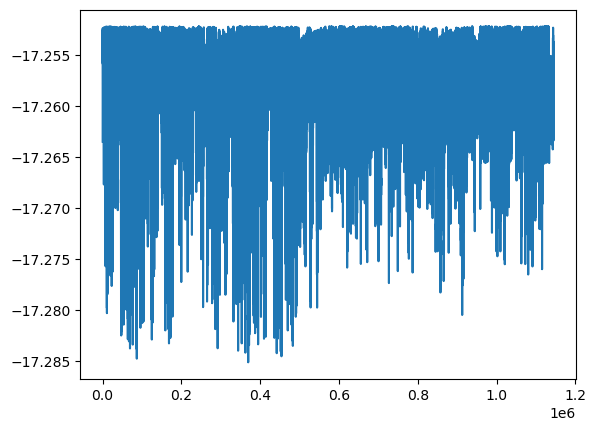

In [132]:
plt.figure()
plt.plot(std_e_valid_noscale[:,1])

# Develop Polynomial Fitting

In [19]:
import polynomial as p

In [80]:
importlib.reload(p)

<module 'polynomial' from '/glade/u/home/mhayman/Python/aerosol-scattering/library/polynomial.py'>

In [81]:
importlib.reload(evid_nn)

<module 'evid_nn' from '/glade/u/home/mhayman/Python/aerosol-scattering/library/evid_nn.py'>

In [56]:
order1 = 4
order2 = 3
c_mat1 = p.chebyshev_poly(order1,device=device,dtype=dtype)
c_mat2 = p.chebyshev_poly(order2,device=device,dtype=dtype)

In [57]:
c_mat1

tensor([[ 1.,  0., -1.,  0.,  1.],
        [ 0.,  1.,  0., -3.,  0.],
        [ 0.,  0.,  2.,  0., -8.],
        [ 0.,  0.,  0.,  4.,  0.],
        [ 0.,  0.,  0.,  0.,  8.]], device='cuda:0')

In [58]:
y_train.shape

(515073, 2)

In [59]:
y_sub = torch.tensor(y_train[:4,:],dtype=dtype,device=device)

In [60]:
y_sub

tensor([[0.8901, 0.0277],
        [0.8834, 0.0281],
        [0.8811, 0.0269],
        [0.8723, 0.0276]], device='cuda:0')

In [61]:
x1 = y_sub[:,0].reshape(-1,1)
x2 = y_sub[:,1].reshape(-1,1)

In [69]:
x1p = x1**torch.arange(0,order1+1,device=device,dtype=dtype).reshape(1,-1)
x2p = x2**torch.arange(0,order2+1,device=device,dtype=dtype).reshape(1,-1)

In [70]:
x1c = x1p @ c_mat1
x2c = x2p @ c_mat2

Options for performing the outer product between x1p and x2p while preserving the batch dimension:

```torch.einsum('bi,bj->bij', x1, x2)```

```x1.unsqueeze(2) @ x2.unsqueeze(1)```


In [71]:
# this produces a tensor with batch in the 0 dimension and 
# a vector describing the multivariate polynomial (including cross terms) in the 1 dimension
torch.einsum('bi,bj->bij', x1c, x2c).view(y_sub.shape[0], -1)

tensor([[ 1.0000,  0.0277, -0.9985, -0.0830,  0.8901,  0.0247, -0.8887, -0.0739,
          0.5845,  0.0162, -0.5836, -0.0485,  0.1505,  0.0042, -0.1502, -0.0125,
         -0.3167, -0.0088,  0.3162,  0.0263],
        [ 1.0000,  0.0281, -0.9984, -0.0843,  0.8834,  0.0248, -0.8820, -0.0745,
          0.5607,  0.0158, -0.5598, -0.0473,  0.1072,  0.0030, -0.1071, -0.0090,
         -0.3713, -0.0104,  0.3707,  0.0313],
        [ 1.0000,  0.0269, -0.9985, -0.0807,  0.8811,  0.0237, -0.8798, -0.0711,
          0.5526,  0.0149, -0.5518, -0.0446,  0.0928,  0.0025, -0.0926, -0.0075,
         -0.3892, -0.0105,  0.3886,  0.0314],
        [ 1.0000,  0.0276, -0.9985, -0.0829,  0.8723,  0.0241, -0.8710, -0.0723,
          0.5218,  0.0144, -0.5210, -0.0432,  0.0381,  0.0011, -0.0380, -0.0032,
         -0.4554, -0.0126,  0.4547,  0.0377]], device='cuda:0')

In [68]:
c_mat2.shape

torch.Size([4, 4])

In [73]:
x_int = torch.linspace(0,1,100) # integration axis in 1 dimension
x_mesh_int1, x_mesh_int2 = torch.meshgrid(x_int,x_int,indexing='ij')
x_mesh_int = torch.stack([x_mesh_int1.flatten(), x_mesh_int2.flatten()],axis=1)

In [74]:
x_mesh_int.shape

torch.Size([10000, 2])

In [76]:
x_mesh_int1[0:2,0:3]

tensor([[0.0000, 0.0000, 0.0000],
        [0.0101, 0.0101, 0.0101]])

In [79]:
x_mesh_int[:,0].reshape(x_int.shape[0],x_int.shape[0])

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0101, 0.0101, 0.0101,  ..., 0.0101, 0.0101, 0.0101],
        [0.0202, 0.0202, 0.0202,  ..., 0.0202, 0.0202, 0.0202],
        ...,
        [0.9798, 0.9798, 0.9798,  ..., 0.9798, 0.9798, 0.9798],
        [0.9899, 0.9899, 0.9899,  ..., 0.9899, 0.9899, 0.9899],
        [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]])